# ITM Call Floor — Tightening the Algebraic Guaranteed Floor

**Problem with ATM calls**: `floor = N*(S0 - K - C_call) = -N * time_value`.
ATM time value ≈ 18% of TSLL spot (IV ≈ 120%) → guaranteed worst-case loss per cycle ≈ -18%.

**Fix — buy ITM calls (K < S0)**. By no-arbitrage:
$$C_{itm} = (S_0 - K) + TV_{itm}$$
$$\text{floor} = N(S_0 - K - C_{itm}) = N(S_0 - K - (S_0-K) - TV_{itm}) = -N \cdot TV_{itm}$$

Intrinsic cancels exactly. Only time value is the guaranteed per-cycle loss.

| Bucket   | strike/spot | Typical TV%  | Floor depth | Delta |
|----------|:-----------:|:------------:|:-----------:|:-----:|
| ATM      | 1.00        | ~18%         | ~-18%       | 0.62  |
| 5% ITM   | 0.95        | ~14%         | ~-14%       | 0.68  |
| 10% ITM  | 0.90        | ~12%         | ~-12%       | 0.71  |
| 15% ITM  | 0.85        | ~10.6%       | ~-10.6%     | 0.74  |

TSLA fallback: when TSLL ITM fills are unavailable, use ATM TSLA calls at
2× leverage (TSLL_LEVER = 2.0). AZ compounding drift acknowledged; acceptable
for 90-day cycles.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROOT = Path.cwd().resolve().parents[1]  # scripts/utils/ -> project root
sys.path.insert(0, str(ROOT / 'scripts' / 'eda'))
sys.path.insert(0, str(ROOT / 'scripts' / 'backtest'))

from data_loader import (load_tsll, load_tsll_calls,
                         load_tsla_underlying, load_tsla_calls)
from options_selection import select_contract, bs_delta
from metrics import summarize

%matplotlib inline
print('Imports OK')

Imports OK


## Load data

In [2]:
tsll_spot  = load_tsll().set_index('Date')['Close']
tsll_calls = load_tsll_calls()
tsla_spot  = load_tsla_underlying().set_index('Date')['Close'].reindex(tsll_spot.index).ffill()
tsla_calls = load_tsla_calls()

call_lookup = tsll_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()
tsla_lookup = tsla_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()

dates = tsll_spot.index
print(f'TSLL spot : {len(dates):,} days  {dates.min().date()} -> {dates.max().date()}')
print(f'TSLL calls: {tsll_calls["raw_id"].nunique():,} contracts  {len(tsll_calls):,} rows')
print(f'TSLA calls: {tsla_calls["raw_id"].nunique():,} contracts  {len(tsla_calls):,} rows')

TARGET_DTE = 90
MAX_DTE    = 110
TSLL_LEVER = 2.0
R_RF       = 0.05
VOL_WINDOW = 21

r_tsla     = tsla_spot.pct_change()
tsla_sigma = (r_tsla.rolling(VOL_WINDOW).std() * 252**0.5).ffill().bfill()
print('Config set.')

TSLL spot : 963 days  2022-08-09 -> 2026-06-10
TSLL calls: 689 contracts  46,867 rows
TSLA calls: 3,786 contracts  532,258 rows
Config set.


## ITM call moneyness distribution — how many liquid fills exist per bucket?

In [3]:
calls_with_spot = tsll_calls.merge(
    tsll_spot.rename('spot').reset_index().rename(columns={'Date': 'date'}),
    on='date', how='left'
)
calls_with_spot['moneyness'] = calls_with_spot['strike'] / calls_with_spot['spot']
calls_with_spot['dte'] = (calls_with_spot['expiry'] - calls_with_spot['date']).dt.days

active = calls_with_spot[
    (calls_with_spot['dte'] >= 15) & (calls_with_spot['dte'] <= MAX_DTE)
    & calls_with_spot['px_volume'].notna() & (calls_with_spot['px_volume'] > 0)
]
print(f'Liquid call obs (15-{MAX_DTE} DTE, volume>0): {len(active):,}')

bins   = [0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15]
labels = ['<80% (deep ITM)', '80-85% (15% ITM)', '85-90% (10% ITM)',
          '90-95% (5% ITM)', '95-100% (ATM-)', '100-105% (ATM)',
          '105-110% (5% OTM)', '>110% (OTM)']
active = active.copy()
active['mon_bucket'] = pd.cut(active['moneyness'], bins=bins, labels=labels)
print(active.groupby('mon_bucket', observed=True).agg(
    contracts=('raw_id', 'nunique'),
    obs_days =('date', 'nunique'),
    med_premium=('px_last', 'median')
).to_string())

Liquid call obs (15-110 DTE, volume>0): 21,412
                   contracts  obs_days  med_premium
mon_bucket                                         
<80% (deep ITM)          181       374         4.10
80-85% (15% ITM)         217       435         3.60
85-90% (10% ITM)         253       497         3.10
90-95% (5% ITM)          290       583         2.55
95-100% (ATM-)           315       567         2.20
100-105% (ATM)           319       598         1.80
105-110% (5% OTM)        338       596         1.50
>110% (OTM)              341       595         1.25


## `select_itm_call` — ITM/ATM call selector

In [4]:
ITM_CALL_RANGES = {
    'ATM':    (0.95, 1.05),
    '5% ITM':  (0.90, 0.95),
    '10% ITM': (0.85, 0.90),
    '15% ITM': (0.80, 0.85),
}


def select_itm_call(calls_df, spot, date, moneyness_bucket, target_dte, max_dte=None):
    """Pick the TSLL call closest to target_dte in the given moneyness bucket.
    Requires px_volume > 0 (liquid fill).
    """
    lo, hi = ITM_CALL_RANGES[moneyness_bucket]
    day = calls_df[calls_df['date'] == date]
    if day.empty:
        return None
    s = float(spot.loc[date])
    moneyness = day['strike'] / s
    dte = (day['expiry'] - date).dt.days
    mask = (
        (moneyness >= lo) & (moneyness < hi)
        & (dte > 0)
        & day['px_last'].notna() & (day['px_last'] > 0)
        & day['px_volume'].notna() & (day['px_volume'] > 0)
    )
    if max_dte is not None:
        mask = mask & (dte <= max_dte)
    candidates = day[mask]
    if candidates.empty:
        return None
    dte_c = (candidates['expiry'] - date).dt.days
    return candidates.loc[(dte_c - target_dte).abs().idxmin()]


print('select_itm_call defined.')

select_itm_call defined.


## `simulate_itm_floor` — guaranteed floor with configurable call moneyness

Identical accounting to `guaranteed_floor_simple_sandbox.ipynb` but uses
`select_itm_call` instead of `select_contract`.  Per-cycle log records
`time_value` and `tv_pct` so we can verify the math:

```
floor = N*(S0 - K_itm - C_itm) = N*(S0 - K - (S0-K) - TV) = -N*TV
```

TSLA fallback: ATM TSLA calls sized to TSLL_LEVER delta-equivalent (2×).

In [5]:
def simulate_itm_floor(sim_dates, spot, calls, call_lkp, call_bucket,
                       tsla_spot, tsla_calls, tsla_lkp, tsla_sigma,
                       target_dte, max_dte, notional=1.0):
    S_incep     = float(spot.loc[sim_dates[0]])
    n_shares    = notional / S_incep
    n_contracts = n_shares / 100

    equity     = pd.Series(index=sim_dates, dtype=float)
    position   = None
    option_pnl = short_pnl = 0.0
    S_prev     = S_incep
    cycle_log  = []
    current_cycle = None
    n_unhedged = 0

    def mtm_price(pos, d):
        sp  = tsla_spot if pos['underlying'] == 'tsla' else spot
        lkp = tsla_lkp  if pos['underlying'] == 'tsla' else call_lkp
        if d > pos['expiry']:
            return max(float(sp.loc[d]) - pos['strike'], 0.0)
        px = lkp.get((pos['raw_id'], d))
        return float(px) if px is not None and not pd.isna(px) else pos['price']

    for d in sim_dates:
        S_today    = float(spot.loc[d])
        short_pnl += n_shares * (S_prev - S_today)
        S_prev     = S_today

        need_roll = position is None or d > position['expiry']

        if position is not None:
            px = mtm_price(position, d)
            option_pnl      += position['n'] * 100 * (px - position['price'])
            position['price'] = px

        if need_roll:
            eq_now = notional + short_pnl + option_pnl
            if current_cycle is not None:
                current_cycle['end_date']   = d
                current_cycle['equity_end'] = eq_now
                cycle_log.append(current_cycle)

            row = select_itm_call(calls, spot, d, call_bucket, target_dte, max_dte)
            if row is not None:
                entry     = float(row['px_last'])
                intrinsic = max(float(spot.loc[d]) - float(row['strike']), 0.0)
                tv        = entry - intrinsic
                position  = {'underlying': 'tsll', 'raw_id': row['raw_id'],
                             'strike': float(row['strike']), 'expiry': row['expiry'],
                             'n': n_contracts, 'price': entry}
                floor_val = n_shares * (float(spot.loc[d]) - float(row['strike']) - entry)
                current_cycle = {
                    'start_date': d, 'equity_start': eq_now,
                    'floor': floor_val,
                    'time_value': tv, 'tv_pct': tv / float(spot.loc[d]) * 100,
                    'call_cost': entry, 'strike': float(row['strike']),
                    'moneyness': float(row['strike']) / float(spot.loc[d]),
                    'underlying': 'tsll', 'guaranteed': True,
                }
            else:
                row_tsla = select_contract(tsla_calls, tsla_spot, d, 'ATM', target_dte, max_dte)
                if row_tsla is not None:
                    S_tsla = float(tsla_spot.loc[d])
                    sigma  = float(tsla_sigma.loc[d]) if d in tsla_sigma.index else 0.5
                    T      = (row_tsla['expiry'] - d).days / 365.25
                    delta  = bs_delta(S_tsla, float(row_tsla['strike']), T, R_RF, sigma)
                    n_tsla = (TSLL_LEVER * n_shares * float(spot.loc[d])) / (max(delta, 0.01) * 100 * S_tsla)
                    entry  = float(row_tsla['px_last'])
                    position = {'underlying': 'tsla', 'raw_id': row_tsla['raw_id'],
                                'strike': float(row_tsla['strike']), 'expiry': row_tsla['expiry'],
                                'n': n_tsla, 'price': entry}
                    current_cycle = {
                        'start_date': d, 'equity_start': eq_now,
                        'floor': float('nan'), 'time_value': float('nan'), 'tv_pct': float('nan'),
                        'call_cost': entry, 'strike': float(row_tsla['strike']),
                        'moneyness': float(row_tsla['strike']) / float(tsla_spot.loc[d]),
                        'underlying': 'tsla', 'guaranteed': False,
                    }
                else:
                    position = current_cycle = None
                    n_unhedged += 1

        equity.loc[d] = notional + short_pnl + option_pnl

    if current_cycle is not None:
        current_cycle['end_date']   = sim_dates[-1]
        current_cycle['equity_end'] = equity.iloc[-1]
        cycle_log.append(current_cycle)

    return equity, pd.DataFrame(cycle_log), n_unhedged


print('simulate_itm_floor defined.')

simulate_itm_floor defined.


## Run ITM call variants vs ATM baseline

In [6]:
ITM_SCENARIOS = [
    ('ATM (baseline)', 'ATM'),
    ('5% ITM calls',   '5% ITM'),
    ('10% ITM calls',  '10% ITM'),
    ('15% ITM calls',  '15% ITM'),
]

itm_results    = []
itm_equities   = {}
itm_cycle_logs = {}

for label, bucket in ITM_SCENARIOS:
    eq, cdf, n_unk = simulate_itm_floor(
        dates, tsll_spot, tsll_calls, call_lookup, bucket,
        tsla_spot, tsla_calls, tsla_lookup, tsla_sigma,
        TARGET_DTE, MAX_DTE
    )
    itm_equities[label]   = eq
    itm_cycle_logs[label] = cdf

    row = summarize(eq, eq.pct_change().dropna(), label)
    tsll_cdf = cdf[cdf['underlying'] == 'tsll']
    row['TSLL cycles']     = int((cdf['underlying'] == 'tsll').sum())
    row['TSLA fallback']   = int((cdf['underlying'] == 'tsla').sum())
    row['Avg TV%']         = float(tsll_cdf['tv_pct'].mean())  if len(tsll_cdf) else float('nan')
    row['Avg floor depth'] = float(tsll_cdf['floor'].mean())   if len(tsll_cdf) else float('nan')
    itm_results.append(row)
    print(f'Done: {label}  |  TSLL fills: {len(tsll_cdf)}  TSLA fallback: {n_unk}')

itm_df = pd.DataFrame(itm_results)
print('\nAll ITM scenarios complete.')

Done: ATM (baseline)  |  TSLL fills: 12  TSLA fallback: 0
Done: 5% ITM calls  |  TSLL fills: 12  TSLA fallback: 0
Done: 10% ITM calls  |  TSLL fills: 12  TSLA fallback: 0
Done: 15% ITM calls  |  TSLL fills: 11  TSLA fallback: 0

All ITM scenarios complete.


## Results — ITM call variants

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

show = ['Strategy', 'CAGR', 'Ann. Vol', 'Sharpe', 'Max DD', 'Calmar',
        'TSLL cycles', 'TSLA fallback', 'Avg TV%', 'Avg floor depth']
print(itm_df[[c for c in show if c in itm_df.columns]].to_string(index=False))

      Strategy    CAGR  Ann. Vol  Sharpe  Max DD  Calmar  TSLL cycles  TSLA fallback  Avg TV%  Avg floor depth
ATM (baseline)  0.1663    0.2570  0.7300 -0.2213  0.7516           12              4  17.4018          -0.1171
  5% ITM calls  0.1645    0.2704  0.7010 -0.2223  0.7403           12              6  11.9768          -0.0833
 10% ITM calls -0.1461    0.4001 -0.1978 -0.6603 -0.2213           12              7   8.8811          -0.0535
 15% ITM calls  0.1620    0.2790  0.6795 -0.2555  0.6339           11              7   9.0906          -0.0650


## Equity curves — ITM variants vs ATM baseline

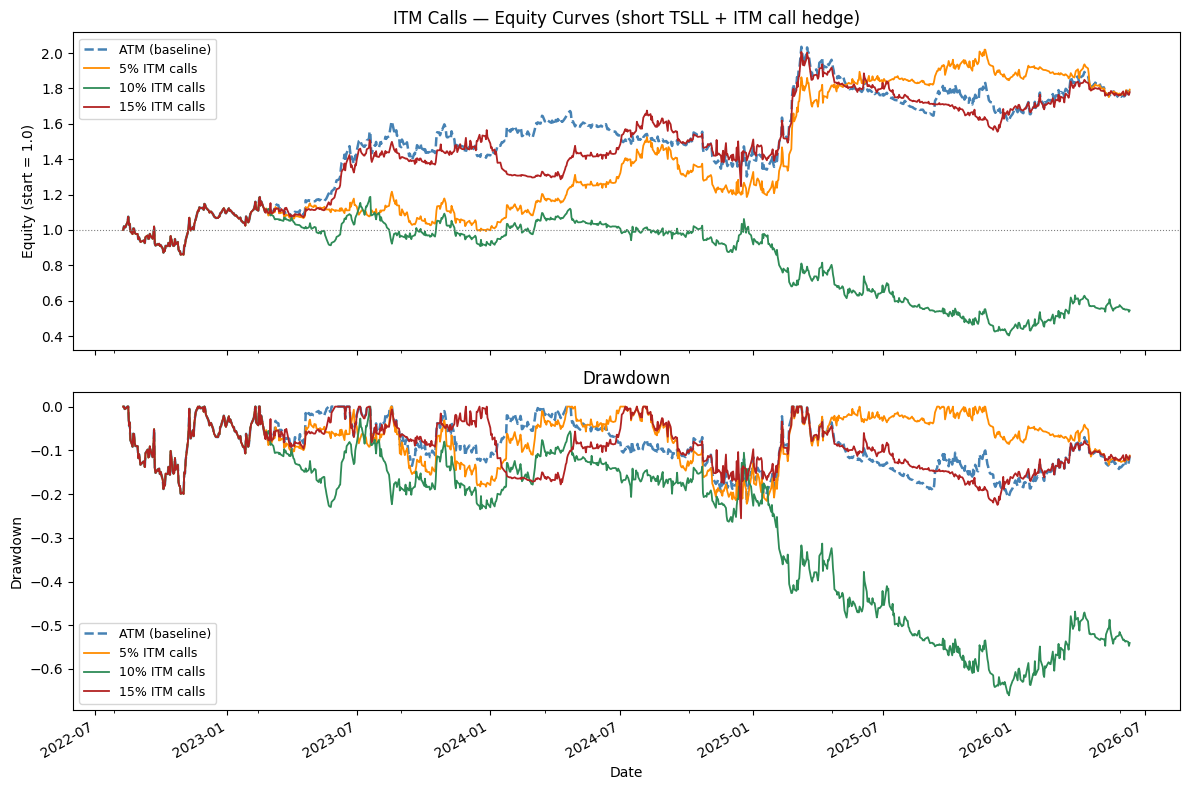

In [8]:
colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for (label, _), color in zip(ITM_SCENARIOS, colors):
    eq = itm_equities[label]
    ls = '--' if label == 'ATM (baseline)' else '-'
    lw = 1.8  if label == 'ATM (baseline)' else 1.3
    eq.plot(ax=axes[0], label=label, color=color, linestyle=ls, linewidth=lw)
    (eq / eq.cummax() - 1).plot(ax=axes[1], label=label, color=color, linestyle=ls, linewidth=lw)

axes[0].axhline(1.0, color='grey', linestyle=':', linewidth=0.8)
axes[0].set_title('ITM Calls — Equity Curves (short TSLL + ITM call hedge)')
axes[0].set_ylabel('Equity (start = 1.0)')
axes[0].legend(fontsize=9)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].legend(fontsize=9)
fig.tight_layout()

out_dir = ROOT / 'observations' / 'strategies' / 'sandbox'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'itm_call_floor.png', dpi=150, bbox_inches='tight')
plt.show()

## Per-cycle floor depth — ATM vs 15% ITM

Each bar = realized P&L for that cycle as % of equity at cycle start.  
Red step line = algebraic floor (= -time_value_pct, guaranteed not to breach).

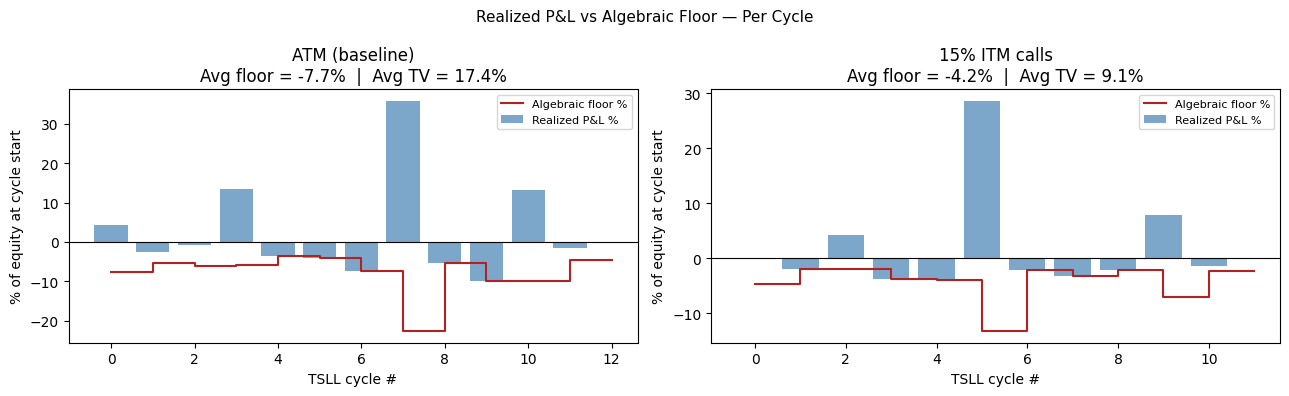

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, label in zip(axes, ['ATM (baseline)', '15% ITM calls']):
    cdf = itm_cycle_logs[label]
    tsll_cdf = cdf[cdf['underlying'] == 'tsll'].copy()
    tsll_cdf['realized_pnl'] = tsll_cdf['equity_end'] - tsll_cdf['equity_start']
    tsll_cdf['floor_pct']    = tsll_cdf['floor'] / tsll_cdf['equity_start'] * 100
    tsll_cdf['realized_pct'] = tsll_cdf['realized_pnl'] / tsll_cdf['equity_start'] * 100
    x = list(range(len(tsll_cdf)))
    ax.bar(x, tsll_cdf['realized_pct'].values, color='steelblue', alpha=0.7, label='Realized P&L %')
    floor_vals = list(tsll_cdf['floor_pct'].values)
    ax.step(x + [len(x)], floor_vals + [floor_vals[-1]],
            where='post', color='firebrick', linewidth=1.5, label='Algebraic floor %')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{label}\nAvg floor = {tsll_cdf["floor_pct"].mean():.1f}%  |  '
                 f'Avg TV = {tsll_cdf["tv_pct"].mean():.1f}%')
    ax.set_xlabel('TSLL cycle #')
    ax.set_ylabel('% of equity at cycle start')
    ax.legend(fontsize=8)

fig.suptitle('Realized P&L vs Algebraic Floor — Per Cycle', fontsize=11)
fig.tight_layout()
plt.show()

## Per-cycle detail log — all scenarios

In [10]:
for label, _ in ITM_SCENARIOS:
    cdf = itm_cycle_logs[label].copy()
    tsll_cdf = cdf[cdf['underlying'] == 'tsll']
    print(f'\n=== {label} ===')
    show_cols = [c for c in ['start_date', 'end_date', 'underlying', 'guaranteed',
                              'moneyness', 'call_cost', 'time_value', 'tv_pct',
                              'floor', 'equity_start', 'equity_end'] if c in cdf.columns]
    print(cdf[show_cols].to_string(index=False))
    if len(tsll_cdf):
        print(f'  Avg TV%: {tsll_cdf["tv_pct"].mean():.2f}%  |  '
              f'Min TV%: {tsll_cdf["tv_pct"].min():.2f}%  |  '
              f'Avg floor: {tsll_cdf["floor"].mean():.4f}')


=== ATM (baseline) ===
start_date   end_date underlying  guaranteed  moneyness  call_cost  time_value  tv_pct   floor  equity_start  equity_end
2022-08-09 2022-11-21       tsla       False     0.9647    41.4300         NaN     NaN     NaN        1.0000      1.1105
2022-11-21 2023-02-21       tsla       False     0.9531    27.2500         NaN     NaN     NaN        1.1105      1.1195
2023-02-21 2023-04-24       tsll        True     0.9877     2.2000      2.0500 16.8724 -0.0850        1.1195      1.1684
2023-04-24 2023-07-24       tsla       False     0.9843    18.8800         NaN     NaN     NaN        1.1684      1.4694
2023-07-24 2023-09-18       tsll        True     1.0056     1.7600      1.7600  9.8324 -0.0771        1.4694      1.4312
2023-09-18 2023-12-18       tsll        True     0.9807     2.4500      2.1200 12.4267 -0.0879        1.4312      1.4213
2023-12-18 2024-03-18       tsll        True     0.9919     2.1000      1.9800 13.3333 -0.0821        1.4213      1.6140
2024-03-

## Guarantee verification — ITM variants

For every TSLL cycle the realized P&L must be >= algebraic floor (within 1e-6).

In [11]:
print(f"{'Scenario':<22} {'TSLL cyc':>9} {'Breaches':>9} {'Avg floor%':>11} {'Worst floor%':>13} {'Status'}")
print('-' * 75)
for label, _ in ITM_SCENARIOS:
    cdf = itm_cycle_logs[label].copy()
    cdf['realized_pnl'] = cdf['equity_end'] - cdf['equity_start']
    cdf['breach']       = cdf['guaranteed'] & (cdf['realized_pnl'] < (cdf['floor'] - 1e-6))
    tsll_cdf  = cdf[cdf['underlying'] == 'tsll']
    floor_pct = tsll_cdf['floor'] / tsll_cdf['equity_start'] * 100 if len(tsll_cdf) else pd.Series(dtype=float)
    tsll_n    = len(tsll_cdf)
    n_breach  = int(cdf['breach'].sum())
    avg_f     = float(floor_pct.mean()) if len(floor_pct) else float('nan')
    worst_f   = float(floor_pct.min())  if len(floor_pct) else float('nan')
    status    = 'GUARANTEE HELD' if n_breach == 0 else f'BREACHED x{n_breach}'
    print(f'{label:<22} {tsll_n:>9} {n_breach:>9} {avg_f:>10.1f}% {worst_f:>12.1f}%  {status}')

Scenario                TSLL cyc  Breaches  Avg floor%  Worst floor% Status
---------------------------------------------------------------------------
ATM (baseline)                12         0       -7.7%        -22.7%  GUARANTEE HELD
5% ITM calls                  12         0       -6.4%        -20.7%  GUARANTEE HELD
10% ITM calls                 12         0       -8.5%        -28.6%  GUARANTEE HELD
15% ITM calls                 11         0       -4.2%        -13.3%  GUARANTEE HELD
